# Problem 1: Skewness and Kurtosis Comparison
# We are given two portfolios:

## Portfolio A: Skewness = -0.75, Kurtosis = 6.06
## Portfolio B: Skewness = 0, Kurtosis = 3
Explanation
Skewness Interpretation

A negative skewness (A) means the portfolio has a long left tail, implying a higher probability of extreme negative returns.
A zero skewness (B) means a symmetric return distribution (normal distribution).
Kurtosis Interpretation

Portfolio A (kurtosis = 6.06) has higher kurtosis, meaning it has more extreme values (fatter tails), making it riskier.
Portfolio B (kurtosis = 3) follows a normal distribution with no excess kurtosis.

* Which Portfolio is Better?

Portfolio A has more downside risk due to negative skewness and higher kurtosis.
Portfolio B is preferable because it has lower tail risk and a more symmetric distribution.
* Answer: Portfolio B is preferable due to its more stable and symmetric return distribution.



# Problem 2: Compute 80% Conditional Value At Risk 
 ## Sort the returns in ascending order

In [2]:
import numpy as np

# Given monthly returns
returns = np.array([-4, 5, 2, -7, 1, 0.5, -2, -1, -2, 5]) / 100  # Convert to decimal

# 80% CVaR Calculation
var_80 = np.percentile(returns, 20)  # 20th percentile (VaR at 80%)
cvar_80 = returns[returns <= var_80].mean()  # CVaR is the average of losses below VaR

print("80% VaR:", var_80)
print("80% CVaR:", cvar_80)


80% VaR: -0.024
80% CVaR: -0.05500000000000001


 * Answer.  80% VaR is the 20 th percentile return
* 80% CVaR is the average of returns below the 80% VaR threshold.

# Problem 3: Compute 95% Gaussian VaR

In [5]:
mu = 0.5 / 100  # Expected return in decimal
sigma = 4 / 100  # Volatility in decimal
z_95 = -1.65  # Z-score for 95% confidence

var_95 = mu + z_95 * sigma
print("95% Gaussian VaR:", var_95)


95% Gaussian VaR: -0.061000000000000006


* This means we expect at worst a 6.1% loss in a month with 95% confidence
or We are 95% confident that we will not lose more than 6.1% loss at worst case scenario

# Problem 4: Modified Critical Value Using Cornish-Fisher Expansion

In [10]:
z = -1.65
skew = -1.2
kurtosis = 6

z_modified = z + ((z**2 - 1) * skew / 6) + ((z**3 - 3*z) * (kurtosis - 3) / 24)
print("Modified 95% Critical Value:", z_modified)


Modified 95% Critical Value: -1.937265625


* The modified critical value will be more negative than (1.65), reflecting higher tail risk


# Problem 5 : Define drawdown and it's relevance
Drwadown is the percentage decline from the peak value of a portfolio to it's point before a new peak is achieved.

# Is drawdown a measure of downside risk?
Yes, because it directly measure losses.
A portfolio with frequent deep drawdowns is riskier beacuse it takes longer to recover

# Problem 6 : Drawdown of a Risk-free Investment
Assumption: Risk-free return is constant every month
Drawdown Calculation:
If an investment always earns the risk-free rate, then it never decreases in value 
Maximum drawdown: 0%

* Drawdown = 0% because the investment never declines

In [2]:
# Problem 7: 

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import scipy.stats as scs

In [5]:
returns = pd.read_csv("Downloads/Cleaned_Value_Weighted_OP_Returns.csv",
                     header = 0, index_col = 0, parse_dates = True, na_values = -99.99)
# Load the file
file_path = "Downloads/Cleaned_Value_Weighted_OP_Returns.csv"
df = pd.read_csv(file_path)

# Select lines 730 to 1145 (Remember: Python uses zero-based indexing)
lines_730_1145 = df.iloc[729:1145]  # 729 corresponds to line 730 in human terms

# Display the selected rows
(lines_730_1145)

,Date,Lo 30,Med 40,Hi 30,Lo 20,Qnt 2,Qnt 3,Qnt 4,Hi 20,Lo 10,Dec 2,Dec 3,Dec 4,Dec 5,Dec 6,Dec 7,Dec 8,Dec 9,Hi 10
729,2024-04-01,-6.58,-3.00,-4.00,-7.17,-4.50,-3.78,-2.69,-4.41,-8.83,-6.16,-5.85,-2.97,-3.23,-4.08,-2.00,-3.22,-5.68,-3.22
730,2024-05-01,1.81,3.77,6.61,0.99,3.63,2.77,7.28,5.18,0.19,1.46,2.82,4.52,3.08,2.59,4.74,9.26,3.65,6.58
731,2024-06-01,0.50,1.87,4.77,1.70,-1.31,1.97,4.43,4.45,4.14,0.28,-0.94,-1.72,0.46,2.81,3.22,5.34,2.45,6.22
732,2024-07-01,2.51,2.96,0.47,0.21,5.89,7.19,-1.03,0.95,0.81,-0.09,5.41,6.44,8.07,6.37,-1.15,-0.87,-1.26,2.96
733,2024-08-01,0.54,1.47,2.77,-1.00,2.26,1.57,1.75,2.87,-1.67,-0.66,2.37,2.15,0.16,2.90,1.21,2.48,1.52,4.05
734,2024-09-01,2.91,1.85,2.20,3.97,1.44,2.70,2.07,1.90,1.25,5.33,1.69,1.15,5.65,-0.02,1.33,3.05,1.27,2.43
735,2024-10-01,-0.16,1.03,-2.03,0.78,-0.65,-1.07,1.96,-2.96,1.06,0.64,-1.26,0.05,-2.25,0.09,3.05,0.54,-3.56,-2.45
736,2024-11-01,10.74,8.65,4.65,13.64,7.06,10.35,6.58,4.51,14.86,13.04,7.25,6.86,13.04,7.79,7.74,5.03,5.02,4.10
737,2024-12-01,-6.03,-3.62,-1.24,-6.26,-5.41,-4.21,-2.04,-1.32,-7.97,-5.40,-5.74,-5.05,-0.56,-7.84,-2.76,-1.04,-4.28,1.16


In [8]:
columns = ['Lo 10', 'Dec 5']
returns = returns[columns]
returns.head(5)

,Lo 10,Dec 5
Date,,
1963-07-01,-1.44,-0.84
1963-08-01,5.53,5.62
1963-09-01,-3.02,2.21
1963-10-01,0.77,3.41
1963-11-01,0.18,2.05


<Axes: xlabel='Date'>

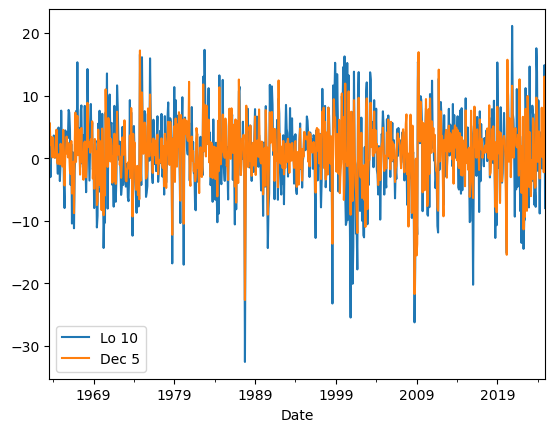

In [10]:
returns.plot()

In [12]:
annual_vol = returns.std() * np.sqrt(12)
annual_vol

Lo 10    22.915130
Dec 5    16.257634
dtype: float64

In [14]:
 returns.shape

(738, 2)

In [16]:
n_months = returns.shape[0]
n_years = n_months/12
n_years

61.5

In [18]:
annual_ret = (1+returns).prod() ** (1/n_years) - 1
annual_ret

Lo 10   -1.0
Dec 5    NaN
dtype: float64

In [20]:
rf = 0.03
sharpe_ratio = (annual_ret - rf) / annual_vol
sharpe_ratio

Lo 10   -0.044948
Dec 5         NaN
dtype: float64